# projection_latlon_to_equal

该命令用于将经纬度投影转换为等距的兰勃特等角圆锥投影. 
部分后处理命令(例如邻域概率预报)，需基于等距网格投影.
* 输入数据投影需为经纬度投影
* 输出数据为等距兰勃特网格投影

In [1]:
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import matplotlib.colors as mcols
import matplotlib.pyplot as plt

import iris
import iris.plot as iplt
from iris.cube import CubeList

from nmc_met_graphics.plot.mapview import add_china_map_2cartopy

import nimm.cli as nimmcli
from nimm import config
from nimm.io.load import load_cube
from nimm.utils.filesystem import FileSystem, filename_update

test_dir = config['test_dir']

## 使用命令转换数值模式投影

In [3]:
# 显示命令信息
! ../../bin/nimm tran_projection-latlon-to-equal --help

Usage: nimm projection-latlon-to-equal [OPTIONS] cube

Transform cube with Longitude/Latitutde projection to Lambert Conformal
projection.

Arguments:
  cube                 Cube with Longitude/Latitutde projection. (type:
                       INPUTCUBE)

Options:
  --projection-extent=COMMA_SEPARATED_LIST_OF_FLOAT
                       The output cube's map projection extent, (xmin, xmax,
                       ymin, ymax).  If None, projection_extent will be set to
                       (83, 138, 12, 53).
  --secant-latitudes=COMMA_SEPARATED_LIST_OF_FLOAT
                       The standard parallels of cone in Lambert Conformal
                       projection.  If None, (25.0, 47.0) is default.
  --grid-distance=FLOAT
                       The grid distance of output cube in meters. Defaults to
                       1000 meters. (default: 1000)
  --regrid-mode=STR    Mode of interpolation in regridding. Valid options are
                       "bilinear", "nearest". Defaults

In [2]:
# 对单个文件进行坐标转换
frt = "20220626T0000Z"  # model forecast reference time
datafile = FileSystem(file_dir=test_dir, data_name="cma_meso",
                      var_name="precipitation_amount", frt=frt,
                      fp=13, time_length=1)
command = f"""../../bin/nimm tran_projection-latlon-to-equal \
    {datafile.get()} \
    --projection-extent=112,124,33,40 \
    --grid-distance=1000 \
    --output={datafile.get(region='HuangHuai')}
    """
!$command

File /media/kan-dai/work01/.nimm/test/cma_meso/precipitation_amount/20220626T0000Z/DN~cma_meso~VN~precipitation_amount~FRT~20220626T0000Z~FP~13~VT~20220626T1300Z~TL~1~RG~HuangHuai.nc already exists.


In [2]:
# find files
datafile = FileSystem(file_dir=test_dir, data_name="cma_meso",
                      var_name="precipitation_amount")
files = datafile.find("**/*~TL~1.nc")
for file in files:
    outfile = filename_update(file, region='HuangHuai')
    command = f"""../../bin/nimm tran_projection-latlon-to-equal \
        {file} --projection-extent=112,124,33,40 \
        --grid-distance=1000 --output={outfile} """
    !$command

File /media/kan-dai/work01/.nimm/test/cma_meso/precipitation_amount/20220626T0000Z/DN~cma_meso~VN~precipitation_amount~FRT~20220626T0000Z~FP~13~VT~20220626T1300Z~TL~1~RG~HuangHuai.nc already exists.


In [2]:
# 对多个文件进行坐标转换
# model forecast reference time and forcast period
datafile = FileSystem(file_dir=test_dir, data_name="cma_meso",
                      var_name="precipitation_amount")
frts = [datetime(2022,6,26,0) - timedelta(hours=i*3) for i in range(5)] 
fps  = [10, 11, 12, 13]

for idx, frt in enumerate(frts):
    frt = f"{frt:%Y%m%dT%H%MZ}"
    for fp in fps[0:-1]:
        fp = fp + idx*3
        command = f"""../../bin/nimm tran_projection-latlon-to-equal \
            {datafile.get(frt=frt, fp=fp, time_length=1)} \
            --projection-extent=112,124,33,40 \
            --grid-distance=1000 \
            --output={datafile.get(frt=frt, fp=fp, time_length=1, region='HuangHuai')} \
            --compression-level=4 --least-significant-digit=2"""
        !$command

In [5]:
# 显示文件数据信息
frt = "20220626T0000Z"
datafile = FileSystem(file_dir=test_dir, data_name="cma_meso",
                      var_name="precipitation_amount", frt=frt, fp=13, 
                      time_length=1, region='HuangHuai')
cube = load_cube(f"{datafile.get()}")
cube

<iris 'Cube' of precipitation_amount / (kg m-2) (realization: 1; projection_y_coordinate: 762; projection_x_coordinate: 1055)>

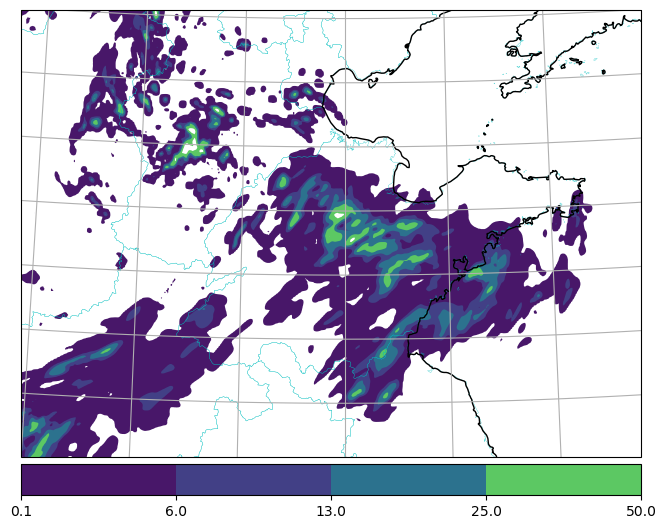

In [6]:
# 显示模式结果
plt.figure(figsize=[8,9])
cnf = iplt.contourf(cube[0], levels=[0.1, 6, 13, 25, 50])
bar = plt.colorbar(cnf, orientation="horizontal", pad=0.01)
ax = plt.gca()
add_china_map_2cartopy(ax, lw=0.2)
ax.coastlines()
ax.gridlines()
iplt.show()

## 调用函数来进行地图投影转换

In [6]:
# 直接读入原始数据, 进行地图投影转换
frt = "20220626T0000Z"
datafile = FileSystem(file_dir=test_dir, data_name="cma_meso",
                      var_name="precipitation_amount", frt=frt, fp=13, 
                      time_length=1)
cube = load_cube(f"{datafile.get()}")
data = nimmcli.tran_projection_latlon_to_equal.process(
    cube, projection_extent=(112,124,33,40))
data

<iris 'Cube' of precipitation_amount / (kg m-2) (realization: 1; projection_y_coordinate: 762; projection_x_coordinate: 1055)>

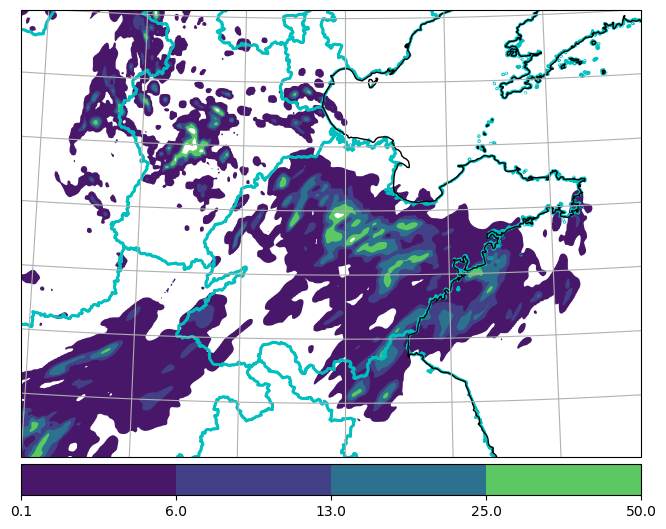

In [7]:
# 显示模式结果
plt.figure(figsize=[8,9])
cnf = iplt.contourf(data[0], levels=[0.1, 6, 13, 25, 50])
bar = plt.colorbar(cnf, orientation="horizontal", pad=0.01)
ax = plt.gca()
add_china_map_2cartopy(ax)
ax.coastlines()
ax.gridlines()
iplt.show()